In [1]:
%load_ext autoreload
%autoreload 2

import copy, csv, gzip, os, re, sys, subprocess, json
import contextlib, random, glob, shutil, warnings, math
from math import ceil
import gzip, random
from collections import defaultdict, Counter
import statsmodels.api as sm


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from math import ceil, sqrt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

import textwrap
from typing import Dict, Tuple, Union, IO, Iterator, Set

In [2]:
def fit_power(x, y):
    # Log-transform
    log_x = np.log(x)
    log_y = np.log(y)
    
    # Weights = original y values
    weights = y
    
    # Add constant for intercept
    X = sm.add_constant(log_x)
    
    # Weighted least squares fit
    model = sm.WLS(log_y, X, weights=weights)
    results = model.fit()
    
    # Extract parameters
    log_a = results.params[0]
    b = results.params[1]
    a = np.exp(log_a)
    
    print(f"Fitted model: y = {a:.4f} * x^{b:.4f}")
    print(results.summary())
    
    # Predict and plot
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = a * x_fit**b
    
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data')
    plt.plot(x_fit, y_fit, color='red', label=f'Weighted Fit: y = {a:.2f} * x^{b:.2f}')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Weighted Log-Log Fit (Power Law)')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

    return(a, b)

In [3]:
def _open_maybe_gzip(path: str) -> IO[bytes]:
    """
    Open a file that may be plain text or gzipped, returning a binary file object.
    """
    # Heuristic: if name ends with .gz open with gzip, else try normal open.
    if path.endswith(".gz"):
        return gzip.open(path, "rb")
    return open(path, "rb")

def _parse_bed_and_sum_lengths(path: str,
                               valid_types=("vector", "itr", "insert")) -> Dict[str, int]:
    """
    Parse a BED-like file and sum lengths per region type.

    Assumptions:
      - BED columns: chrom, start, end, [name/annotation/...]
      - Region type appears in a text column (commonly the 4th column).
      - Lines starting with '#' are comments and skipped.
      - Start and end are integers; length = max(0, end - start).
    """
    totals = {t: 0 for t in valid_types}

    def detect_type_from_fields(fields: list) -> Union[str, None]:
        """
        Try to detect the region type by scanning any textual field for a match.
        """
        for f in fields[3:]:  # prioritize textual columns after the first 3 numeric ones
            lower = f.strip().lower()
            for t in valid_types:
                # exact match or token present in composite names (e.g., 'sample_insert_A')
                if lower == t or t in lower.split("|") or t in lower.split(",") or t in lower.split(";") or t in lower:
                    return t
        # As a fallback, scan all fields
        for f in fields:
            lower = f.strip().lower()
            for t in valid_types:
                if lower == t or t in lower:
                    return t
        return None

    with _open_maybe_gzip(path) as fh:
        for raw_line in fh:
            line = raw_line.decode("utf-8", errors="replace").strip()
            if not line or line.startswith("#"):
                continue
            fields = line.split("\t")
            if len(fields) < 3:
                # Not enough columns to be a BED entry
                continue
            try:
                start = int(fields[1])
                end = int(fields[2])
            except ValueError:
                # Skip malformed lines
                continue
            length = max(0, end - start)
            rtype = detect_type_from_fields(fields)
            if rtype in totals:
                totals[rtype] += length

    return totals

def compare_region_lengths(file1: str, file2: str) -> Dict[str, Dict[str, Union[int, float]]]:
    """
    Compute total length per region type (vector, ITR, insert) for two BED files
    and the per-region length ratio (file2/file1).

    Parameters
    ----------
    file1 : str
        Path to the first BED file.
    file2 : str
        Path to the second BED file.

    Returns
    -------
    Dict[str, Dict[str, Union[int, float]]]
        A dictionary keyed by region type with:
          - 'file1_total': total length in file1
          - 'file2_total': total length in file2
          - 'ratio_file2_over_file1': file2_total / file1_total (float; None if file1_total==0)
    """
    valid_types = ("vector", "itr", "insert")
    totals1 = _parse_bed_and_sum_lengths(file1, valid_types=valid_types)
    totals2 = _parse_bed_and_sum_lengths(file2, valid_types=valid_types)

    result = {}
    for t in valid_types:
        f1 = totals1.get(t, 0)
        f2 = totals2.get(t, 0)
        ratio = (f2 / f1) if f1 != 0 else None
        result[t] = {
            "file1_total": f1,
            "file2_total": f2,
            "ratio_file2_over_file1": ratio,
        }
    return result


In [4]:
def count_positions_in_regions(bed_filename, positions,
                               positions_are_1_based=True,
                               bed_is_0_based_half_open=True):
    """
    Count how many positions fall within any interval of each region name from a BED file.

    Parameters
    ----------
    bed_filename : str
        Path to a BED file with at least 4 columns: chrom, start, end, name.
        Supports plain text and .gz compressed files.
    positions : list of tuples
        List of (chrom, pos) positions to check. Example: [('chr1', 12345), ('chr2', 67890)]
    positions_are_1_based : bool, default True
        If True, converts positions to 0-based to match standard BED conventions.
    bed_is_0_based_half_open : bool, default True
        If True, treats BED intervals as [start, end) (standard BED). If False, treats as closed [start, end].

    Returns
    -------
    dict
        Mapping: region_name -> number of positions that fall within any of its intervals.
        If a position is within overlapping intervals that share the same name, it is counted once for that name.
    """
    # --- Helper: open possibly gzipped file ---
    def _open_maybe_gzip(path):
        return gzip.open(path, "rt") if path.endswith(".gz") else open(path, "r")

    # --- Parse BED and build sweep events per chromosome ---
    # For each chromosome, we create a list of events:
    #   (coord, kind_order, name) where kind_order = 0 for 'end', 1 for 'start'
    # Ordering 'end' before 'start' at the same coordinate ensures half-open semantics.
    chrom_events = defaultdict(list)

    with _open_maybe_gzip(bed_filename) as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 4:
                # Skip lines that don't have name column
                continue
            chrom, start_str, end_str, name = cols[0], cols[1], cols[2], cols[3]
            try:
                start = int(start_str)
                end = int(end_str)
            except ValueError:
                # Skip malformed numeric fields
                continue
            if start > end:
                # Swap if needed (defensive)
                start, end = end, start

            if bed_is_0_based_half_open:
                # Standard BED: active for positions p where start <= p < end
                # We'll sweep with 'end' events before 'start' at identical coords.
                chrom_events[chrom].append((end, 0, name))   # 'end'
                chrom_events[chrom].append((start, 1, name)) # 'start'
            else:
                # Closed intervals [start, end]: active for start <= p <= end
                # To implement closed intervals in a sweep, we can make 'end' at end+1,
                # so active range becomes [start, end+1) under half-open sweep logic.
                chrom_events[chrom].append((end + 1, 0, name)) # 'end' after end
                chrom_events[chrom].append((start, 1, name))    # 'start'

    # --- Normalize positions to 0-based if the input is 1-based ---
    # We won't change BED coordinates; we only adjust positions.
    norm_positions_by_chrom = defaultdict(list)
    for idx, (chrom, pos) in enumerate(positions):
        if positions_are_1_based:
            pos0 = pos - 1
        else:
            pos0 = pos
        norm_positions_by_chrom[chrom].append((pos0, idx))

    # --- Sweep per chromosome ---
    result_counts = Counter()

    for chrom, pos_list in norm_positions_by_chrom.items():
        if not pos_list:
            continue

        # Sort positions for sweep, but keep mapping back to original order if needed
        pos_list.sort(key=lambda t: t[0])

        # Sort events: by coordinate, then kind_order (end=0 before start=1)
        events = chrom_events.get(chrom, [])
        events.sort(key=lambda e: (e[0], e[1]))

        active_name_multiset = Counter()  # name -> number of active intervals for this name
        ev_i = 0
        n_events = len(events)

        for p, _orig_idx in pos_list:
            # Apply all events with coord <= p
            while ev_i < n_events and events[ev_i][0] <= p:
                coord, kind_order, name = events[ev_i]
                if kind_order == 0:
                    # 'end' event: deactivate one instance
                    if active_name_multiset[name] > 0:
                        active_name_multiset[name] -= 1
                        if active_name_multiset[name] == 0:
                            del active_name_multiset[name]
                else:
                    # 'start' event: activate one instance
                    active_name_multiset[name] += 1
                ev_i += 1

            # All names currently active should be incremented once for this position
            # If multiple intervals of the same name are active, still count once.
            for name in active_name_multiset.keys():
                result_counts[name] += 1

    return dict(result_counts)

In [5]:
def _read_fasta(path: str) -> Iterator[Tuple[str, str]]:
    """
    Simple FASTA reader that yields (seq_id, seq_string).
    - seq_id: first token after '>' (up to first whitespace)
    - seq_string: concatenated sequence lines (uppercased, whitespace removed)
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Input FASTA not found: {path}")

    seq_id = None
    seq_chunks = []
    with open(path, "r") as fh:
        for line in fh:
            line = line.rstrip("\n")
            if not line:
                continue
            if line.startswith(">"):
                if seq_id is not None:
                    seq = "".join(seq_chunks).replace(" ", "").upper()
                    yield (seq_id, seq)
                header = line[1:].strip()
                seq_id = header.split()[0] if header else "unknown"
                seq_chunks = []
            else:
                seq_chunks.append(line.strip())
        if seq_id is not None:
            seq = "".join(seq_chunks).replace(" ", "").upper()
            yield (seq_id, seq)


def tile_fasta(
    input_fasta: str,
    output_fasta: str,
    tile_len: int = 120,
    spacing: int = 40,
    dedup_global: bool = True,
) -> None:
    """
    Read sequences from `input_fasta`, chop into tiles of length `tile_len`
    with stride `spacing` (3× tiling implies spacing = tile_len/3),
    and write each NON-DUPLICATE tile as a separate FASTA entry to `output_fasta`.

    Behavior:
      - No line wrapping: each tile sequence is written on a single line.
      - Duplicates are suppressed using a set of previously emitted sequences.
        * If `dedup_global` = True (default), duplicates are suppressed across all input sequences.
        * If False, duplicates are only suppressed within each source sequence.
      - Uses 1-based start/end coordinates in headers.
      - Only full-length tiles are emitted (no partial tail tiles).

    FASTA header format:
      >{seq_id}|tile_{index}|start:{start}|end:{end}|len:{tile_len}

    Example:
      tile_fasta("input.fa", "tiles.fa", tile_len=120, spacing=40)
    """
    if tile_len <= 0 or spacing <= 0:
        raise ValueError("tile_len and spacing must be positive integers.")
    if spacing > tile_len:
        # Allowed, but usually not intended for dense tiling.
        pass

    emitted_set_global: Set[str] = set()

    with open(output_fasta, "w") as out:
        for seq_id, seq in _read_fasta(input_fasta):
            n = len(seq)
            tile_idx = 0
            emitted_set_local: Set[str] = set()

            # Generate windows: start positions 0..(n - tile_len) step spacing
            for start0 in range(0, n - tile_len + 1, spacing):
                end0 = start0 + tile_len
                tile = seq[start0:end0]  # already uppercase from reader

                # Dedup check
                if dedup_global:
                    if tile in emitted_set_global:
                        continue
                else:
                    if tile in emitted_set_local:
                        continue

                # Passed dedup: record and emit
                emitted_set_global.add(tile)
                emitted_set_local.add(tile)
                tile_idx += 1

                # 1-based coordinates in header
                start1 = start0 + 1
                end1 = end0
                header = (
                    f">{seq_id}|tile_{tile_idx:05d}|start:{start1}|end:{end1}|len:{tile_len}"
                )
                out.write(header + "\n")
                out.write(tile + "\n")  # no wrapping


In [6]:
%%bash
ls ../AAVs/pFZ-CBI-CAG-FXNco3/pFZ-CBI-CAG-FXNco3.bed

../AAVs/pFZ-CBI-CAG-FXNco3/pFZ-CBI-CAG-FXNco3.bed


In [7]:
%%bash
ls

20251112_Pfizer_ISstats.tsv
estimate_params.ipynb


In [8]:
# Read Pfizer data:
df = pd.read_csv("20251112_Pfizer_ISstats.tsv", sep="\t")

# Filter out controls:
m = ((df["Sample_name"].apply(lambda x: x.startswith("FXN"))) & (df["Sample_name"].apply(lambda x: x.endswith("AAV"))))
df = df[m].copy()

In [9]:
df.head(3)

,Sample_name,breakend.1,breakend.2,Length.IS,IS.deletion,IS.insertion,translocation
0,FXNHighAAV,4545,4638,92,0,0,False
1,FXNHighAAV,2130,2227,96,0,33,True
2,FXNHighAAV,821,869,47,0,42,True


In [10]:
# Sort for longest deletions:
df.sort_values("IS.deletion", ascending=False).head()

,Sample_name,breakend.1,breakend.2,Length.IS,IS.deletion,IS.insertion,translocation
378,FXNHighAAV,3247,2970,276,35737251,1,False
178,FXNHighAAV,491,781,288,4008445,0,False
289,FXNHighAAV,3118,3245,126,302579,0,False
273,FXNHighAAV,2641,3244,626,32319,31,False
274,FXNHighAAV,3247,2641,605,32304,9,False


In [11]:
# Sort for longest insertions:
df.sort_values("IS.insertion", ascending=False).head()

,Sample_name,breakend.1,breakend.2,Length.IS,IS.deletion,IS.insertion,translocation
262,FXNHighAAV,2639,3247,607,0,1492,False
239,FXNHighAAV,1,803,801,0,637,False
226,FXNHighAAV,591,494,96,0,80,True
242,FXNHighAAV,2968,3329,337,0,71,False
379,FXNHighAAV,793,3167,372,0,68,False


# Translocation frequency

In [12]:
### Consider deletions longer than 100k as translocations:
m = (df["IS.deletion"] > 1e5)
df.loc[m, "translocation"] = True

### Then print the translocation probability point estimate:
print("Point estimate of translocation probability:", df["translocation"].mean())

Point estimate of translocation probability: 0.025


# Insertion size distribution

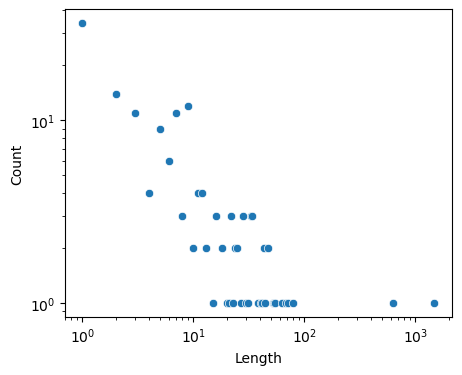

In [13]:
### Plot insertion frequencies ###
m = (df["IS.insertion"] > 0)

# g1 = sns.histplot(data=df[m], x="IS.insertion", binwidth=1)
# g1.set_yscale("log", base=10)
# g1.set_xscale("log", base=10)

ins_df = df[m].groupby("IS.insertion").agg("count").loc[:, ["Sample_name"]].reset_index().rename(columns={"Sample_name": "Count", "IS.insertion": "Length"})


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.scatterplot(ax=ax, data=ins_df, x="Length", y="Count")
g1.set_yscale("log", base=10)
g1.set_xscale("log", base=10)

### This looks like a linear line in log-log space i.e. power law.

Fitted model: y = 28.4000 * x^-0.7488
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.827
Model:                            WLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     200.1
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           1.41e-17
Time:                        18:36:07   Log-Likelihood:                -42.632
No. Observations:                  44   AIC:                             89.26
Df Residuals:                      42   BIC:                             92.83
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

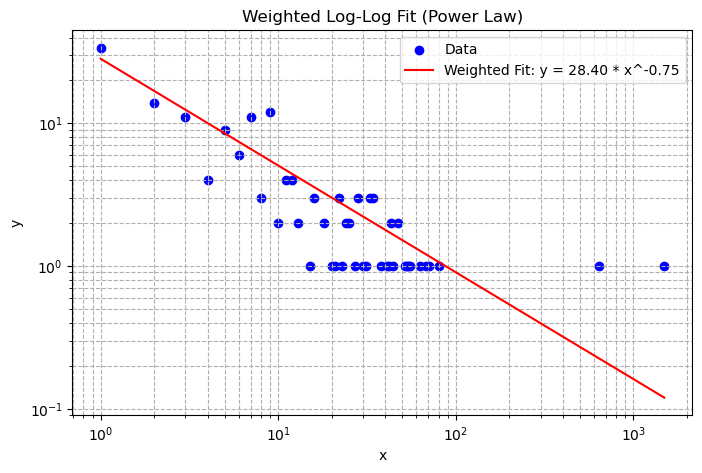

In [14]:
### Fit the power function to the data ###
x = ins_df["Length"].values
y = ins_df["Count"].values
a, b = fit_power(x, y)

In [15]:
# Calculate the probability of any length insertion:
ins_prob = sum(df["IS.insertion"] > 0) / len(df)
print("Probability of no insertion is:", 1 - ins_prob)
print("Probability of no any length insertion is:", ins_prob)

Probability of no insertion is: 0.6625
Probability of no any length insertion is: 0.3375


In [16]:
#### Here, turn this^ into a piece-wise function
# First, uniform for the zero deletion (or more)
# Then the power function, from end the uniform to max_ins
# scale with a parameter like 0.6, 0.4
# uniform_power,0,10000,28.4,-0.7488,0.6625,0.3375

def uniform_power_length(prob1, prob2, max1, max2, a, b):
    mode = random.choices([1, 2], weights=[prob1, prob2], k=1)[0]
    if mode == 1:
        return random.randint(0, max1)
    else:
        x = np.array(range(max1+1, max2+1))
        x_prob = a * x**b
        x_prob = x_prob * 1/x_prob.sum()
        return np.random.choice(x, size=1, p=x_prob)[0]

In [17]:
# Simulate some data from this function:
sim_ins = [uniform_power_length(0.6625, 0.3375, 0, 2000, 28.4, -0.7488) for i in range(int(1e5))]
sim_ins_df = pd.DataFrame({"Length": sim_ins})
sim_ins_df["Count"] = 1
sim_ins_df = sim_ins_df.groupby("Length").agg("sum").reset_index()

Fitted model: y = 1384.0670 * x^-0.7345
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.978
Model:                            WLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                 8.984e+04
Date:                Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:36:10   Log-Likelihood:                -483.60
No. Observations:                1998   AIC:                             971.2
Df Residuals:                    1996   BIC:                             982.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

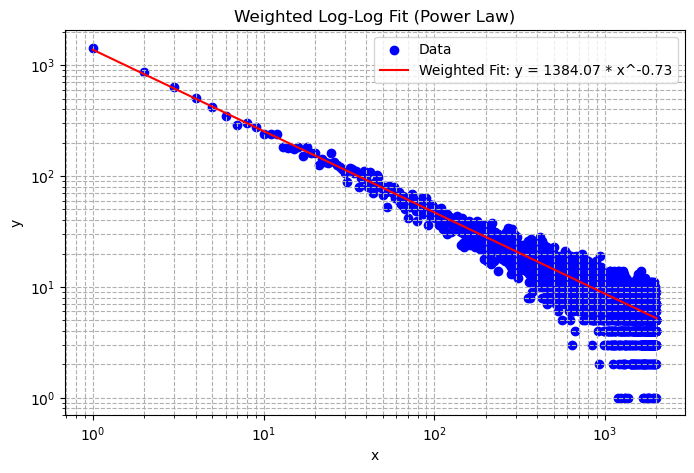

In [18]:
### Plot the simulated data:
m = (sim_ins_df["Length"] > 0)
x = sim_ins_df[m]["Length"].values
y = sim_ins_df[m]["Count"].values
a, b = fit_power(x, y)

# The baseline (a) is shifted because it relates to how many data point are input.
# Otherwise the slope (b) is good.

# Deletion size distribution

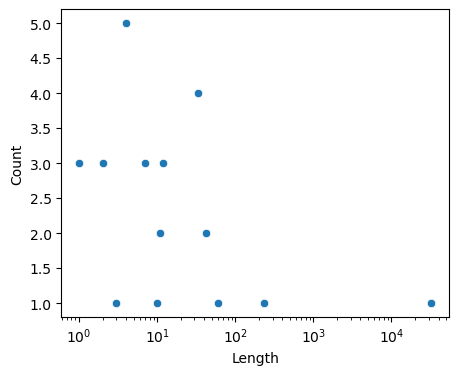

In [19]:
### Plot deletion frequencies ###

m = ((df["IS.deletion"] > 0) & (~df["translocation"]))

# g1 = sns.histplot(data=df[m], x="IS.insertion", binwidth=1)
# g1.set_yscale("log", base=10)
# g1.set_xscale("log", base=10)

del_df = df[m].groupby("IS.deletion").agg("count").loc[:, ["Sample_name"]].reset_index().rename(columns={"Sample_name": "Count", "IS.deletion": "Length"})

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.scatterplot(data=del_df, x="Length", y="Count")
# g1.set_yscale("log", base=10)
g1.set_xscale("log", base=10)

### This looks like a uniform probability between length 1 and 100
### and another uniform probability between length 101 and 100000

In [20]:
### Extract the probabilities for each uniform ###

valid = (~df["translocation"])
l0 = ((df["IS.deletion"] == 0) & valid)
l100 = ((df["IS.deletion"] > 0) & (df["IS.deletion"] <= 100)  & valid)
l100k = ((df["IS.deletion"] > 100) & (df["IS.deletion"] <= 100000)  & valid)
assert((sum(l0) + sum(l100) + sum(l100k)) == sum(valid))

p0 = sum(l0) /sum(valid)
p100 = sum(l100) /sum(valid)
p100k = sum(l100k) /sum(valid)
assert((p0+p100+p100k)==1)

print("Probability of uniform from 0 to 0:", round(p0, 4))
print("Probability of uniform from 1 to 100:", round(p100, 4))
print("Probability of uniform from 101 to 100,000:", round(p100k, 4))

Probability of uniform from 0 to 0: 0.9338
Probability of uniform from 1 to 100: 0.0598
Probability of uniform from 101 to 100,000: 0.0064


# AAV integration lengths

In [21]:
### Plot the distribution of AAV integration lengths ###

In [22]:
df["b2b"] = (df["breakend.1"] - df["breakend.2"] + 1).abs()
intr_df = df.loc[:, ["Length.IS", "b2b"]].melt(var_name="Integration type", value_name="Length").copy()

In [23]:
all_brkn = list(df["breakend.1"].values) + list(df["breakend.2"].values) 

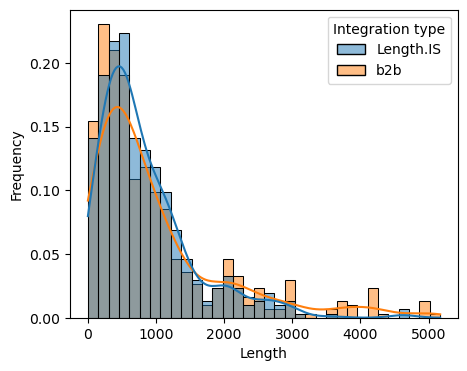

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.histplot(ax=ax, data=intr_df, x="Length", hue="Integration type", stat="frequency", kde=True)

# The IS length (including rearrangements) is roughly corresponding to
# the linear breakend to breakend distance. Use this because there
# is currently no good way to simulate the rearrangements.

In [25]:
### Scale the data for pFZ-CBI-CAG-FXNco3 to the other vectors ###
def map_pos(cmp, fnam):
    p2 = 1
    map12 = dict()
    with open(fnam) as fh:
        for l in fh:
            l = l.strip().split('\t')
            el = l[3].lower()
            for i in range(int(l[1])+1, int(l[2])+1):
                p2 += cmp[el]["ratio_file2_over_file1"]
                map12[i] = round(p2)
    return(map12)


fnam1 = "../AAVs/pFZ-CBI-CAG-FXNco3/pFZ-CBI-CAG-FXNco3.bed"
fnam2 = "../AAVs/rAAVrh74.MHCK7.microdystrophin/rAAVrh74.MHCK7.microdystrophin.bed"
fnam3 = "../AAVs/CMV-EGFP-WPRE/CMV-EGFP-WPRE.bed"

cmp12 = compare_region_lengths(fnam1, fnam2)
cmp13 = compare_region_lengths(fnam1, fnam3)

map12 = map_pos(cmp12, fnam1)
map13 = map_pos(cmp13, fnam1)

df["breakend.1_2"] = df["breakend.1"].apply(lambda x: map12[x])
df["breakend.2_2"] = df["breakend.2"].apply(lambda x: map12[x])
df["breakend.1_3"] = df["breakend.1"].apply(lambda x: map13[x])
df["breakend.2_3"] = df["breakend.2"].apply(lambda x: map13[x])

df["b2b_2"] = (df["breakend.1_2"] - df["breakend.2_2"] + 1).abs()
df["b2b_3"] = (df["breakend.1_3"] - df["breakend.2_3"] + 1).abs()


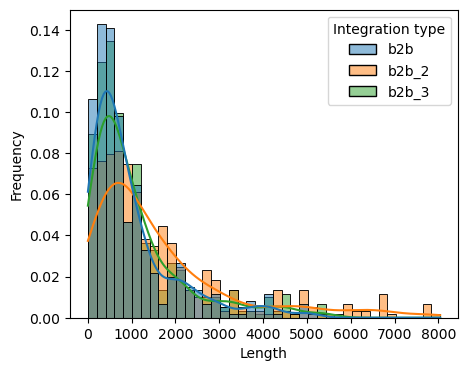

In [26]:
### Plot the scaled AAV integration lengths ###
intr_df2 = df.loc[:, ["b2b", "b2b_2", "b2b_3"]].melt(var_name="Integration type", value_name="Length").copy()

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.histplot(ax=ax, data=intr_df2, x="Length", hue="Integration type", stat="frequency", kde=True)

In [27]:
### Write scaled data for files:
for col, name in zip(["b2b", "b2b_2", "b2b_3"], ["pFZ-CBI-CAG-FXNco3", "rAAVrh74.MHCK7.microdystrophin", "CMV-EGFP-WPRE"]):
    with open(f"../AAVs/{name}/{name}_ISlen.txt", 'w') as fh_out:
        for v in df[col].values:
            print(v, file=fh_out)

# AAV regional breakpoint probabilities

In [28]:
### Count the number of breakends in each region (vector, ITR, insert):
pos_lst = [("pFZ-CBI-CAG-FXNco3", p) for p in df["breakend.1"]]
pos_lst.extend([("pFZ-CBI-CAG-FXNco3", p) for p in df["breakend.2"]])
brkn_cnt = count_positions_in_regions("../AAVs/pFZ-CBI-CAG-FXNco3/pFZ-CBI-CAG-FXNco3.bed", pos_lst)

### Convert to frequency:
brkn_freq = dict()
scale = 100
for reg in brkn_cnt.keys():
    brkn_freq[reg] = round(scale * brkn_cnt[reg] / cmp12[reg.lower()]["file1_total"], 1)
brkn_freq

{'vector': 6.3, 'ITR': 96.9, 'insert': 20.4}

In [29]:
### Write bed breakpoint probability files for each vector:
for name in ["pFZ-CBI-CAG-FXNco3", "rAAVrh74.MHCK7.microdystrophin", "CMV-EGFP-WPRE"]:
    with open(f"../AAVs/{name}/{name}.bed", 'r') as fh_in:
        with open(f"../AAVs/{name}/{name}_breakend_prob.bed", 'w') as fh_out:
            for l in fh_in:
                if l.startswith("#"):
                    print(l, file=fh_out)
                    continue
                cols = l.strip().split('\t')
                prob = brkn_freq[cols[3]]
                cols[3] = str(prob)
                print('\t'.join(cols), file=fh_out)

# Generate target-enrichment oligo panel from AAV genomes

In [30]:
for name in ["pFZ-CBI-CAG-FXNco3", "rAAVrh74.MHCK7.microdystrophin", "CMV-EGFP-WPRE"]:
    f_in = f"../AAVs/{name}/{name}.fa"
    f_out = f"../AAVs/{name}/{name}_tes_panel.fa"
    tile_fasta(f_in, f_out)

In [34]:
%%bash
ls ../simulation_output/testrun/rep1_integration_events.tsv

aav_kde_plot.png
chromosome_lengths.tsv
config.json
reference_check
rep1_all_loci.fa.gz
rep1_episome_loci.fa.gz
rep1_genome_loci.fa.gz
rep1_integration_events.tsv
rep1_integration_loci.fa.gz
rep1_integration_sites.fa.gz
rep1_simulated_reads.fastq.gz


In [41]:
sim = pd.read_csv("../simulation_output/testrun/rep1_integration_events.tsv", sep="\t")

In [42]:
sim["aav_start"]

0      2735
1      2649
2      1519
3      3227
4      4057
       ... 
995     395
996     619
997    1152
998    2277
999    2002
Name: aav_start, Length: 1000, dtype: int64

In [43]:
sim_pos_lst = [("pFZ-CBI-CAG-FXNco3", p) for p in sim["aav_start"]]
sim_pos_lst.extend([("pFZ-CBI-CAG-FXNco3", p) for p in sim["aav_end"]])
sim_brkn_cnt = count_positions_in_regions("../AAVs/pFZ-CBI-CAG-FXNco3/pFZ-CBI-CAG-FXNco3.bed", sim_pos_lst)

In [44]:
brkn_cnt

{'vector': 172, 'ITR': 252, 'insert': 536}

In [45]:
sim_brkn_cnt

{'vector': 281, 'ITR': 453, 'insert': 1266}

In [46]:
sim["ISlen"] = (sim["aav_end"] - sim["aav_start"])

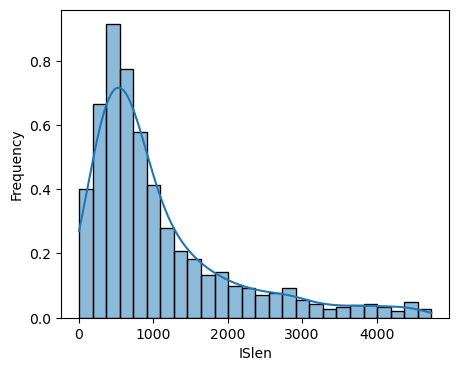

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.histplot(ax=ax, data=sim, x="ISlen", stat="frequency", kde=True)